## Les modules

In [1]:
%load_ext autoreload
%autoreload 1
import nbimporter
import time
from tqdm import tqdm
import numpy as np
from sklearn.datasets import make_blobs,make_circles
from sklearn.metrics import accuracy_score
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.animation as animation
#from mpl_toolkits.mplot3d import Axes3D
import tensorflow_datasets as tfds
import matplotlib as mpl

from IPython.display import HTML
from IPython.display import clear_output
from IPython.display import clear_output, display
import os


## Mise à jours

In [2]:
import sys
import importlib
module_nom= ['AtadiaSah','exemple_fonction_indicatrice','Dataset','sah']
for i in module_nom:
    if i in sys.modules:
        del sys.modules[i]
import AtadiaSah as As
importlib.reload(As)
import exemple_fonction_indicatrice as FI
importlib.reload(FI)
import Dataset
importlib.reload(Dataset)
import sah
importlib.reload(sah)

<module 'sah' from 'sah.ipynb'>

## APPLICATION

## Dataset MNIST

In [3]:
from tensorflow.keras.datasets import mnist

In [4]:
(X_train1, y_train1), (X_test1, y_test1) = mnist.load_data()

X_train=As.normalisation('min_max',X_train1).T
X_test=As.normalisation('min_max',X_test1).T

y_train=Dataset.categories(y_train1,10)
y_test=Dataset.categories(y_test1,10)

#y_train=y_train1.T
#y_test=y_test1.T

taille_train=50000
taille_test=10000

X=X_train.reshape(-1,X_train.shape[-1])[:,:taille_train]
X_test=X_test.reshape(-1,X_test.shape[-1])[:,:taille_test]
X_fiture=X_train.reshape(-1,X_train.shape[-1])[:,taille_train:]

y_x=y_train[:taille_train,:].T
y_test=y_test[:taille_test,:].T

X_train1.shape,X_test1.shape

((60000, 28, 28), (10000, 28, 28))

## 10 IMAGE DU DATASET

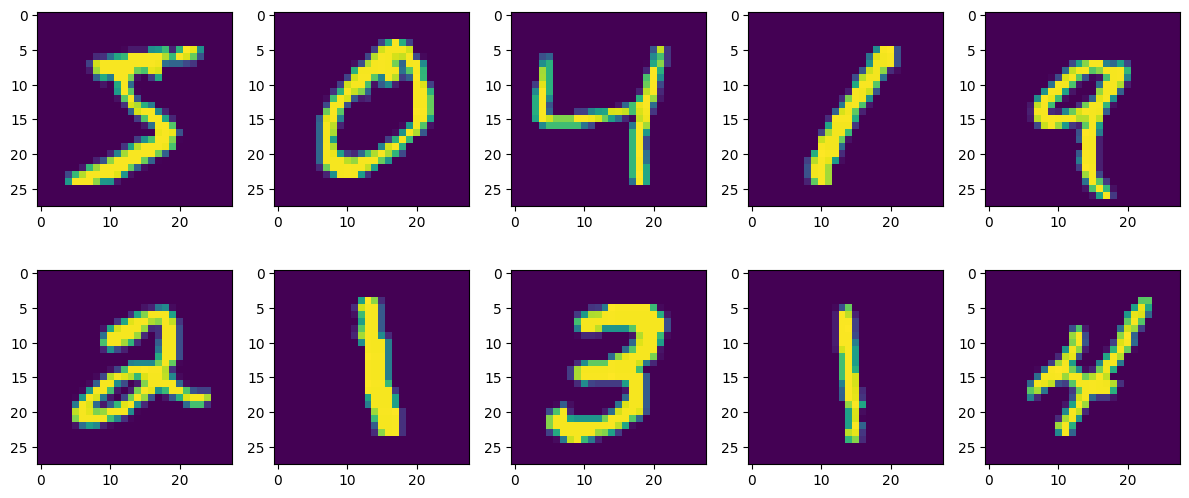

In [5]:
Dataset.visualisation(X_train1,10)

## Réseau

In [5]:
modele=sah.RN()

c1=As.coucheDense(As.fonction_activation('relu',0.1),1,100)
c2=As.coucheDense(As.fonction_activation('relu',0.1),9,100)
c3=As.coucheDense(As.fonction_activation('tanh'),0,100)
c4=As.coucheDense(As.fonction_activation('softmax'),1,10)

modele.add_couche(As.réseau(c1,c2,c3,c4))
modele.add_loss('ECBM')
modele.add_regularisation('elasticnet',0.001,0.001)
modele.add_optimiseur('mini_batch','PD_exp',0.001,1e-9,1000)                                                         #'DGC','PD_exp',0.01,32
modele.add_score('Accuracy_score_multiclasse')           #Accuracy_score_multiclasse


In [7]:
paramètres,cout1,cout2,score1,score2,temps_ecouler=modele.fil(modele,100,1,X,y_x,X_test,y_test)

L'architecture du réseau:[784, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 10]


Apprentissage:loss_trainset:1.289684457,score_trainset:0.919: 100%|█████████████████████████████| 101/101 [28:46<00:00, 17.09s/it]


le socre du modèle est de :0.92


In [ ]:
#modele.continue_fil(modele,100,1)

In [11]:
modele.continue_fil_condition(modele,1,100,1e-9,1)

Apprentissage:loss_trainset:1.202082516,score_trainset:0.944: 100%|█████████████████████████████| 100/100 [29:25<00:00, 17.65s/it]


le socre du modèle est de :0.94


In [12]:
mpl.rcParams['animation.embed_limit'] =5000  

In [13]:
nom='MNIST'
a0=('classificationMultiClasse','MNIST')
a=(X_train1,X_fiture)
taille=('non','non')
ani,figure=modele.evo(modele,a0,a,taille,1e-3,10) 

 95%|██████████████████████████████████████████████████████████████████████████████    | 20/21 [00:54<00:01,  1.82s/it]

## regarder l'animation

In [14]:
HTML(ani.to_jshtml())    

In [15]:
figure.savefig(f'C:/Users/GEMSI\Desktop/Mes images ANN mémoire/{nom}.png')

In [16]:
ani.save(f'C:/Users/GEMSI/Desktop/Mes animation mémoire M2/animation{nom}.mp4', writer='ffmpeg', fps=60)

 91%|█████████████████████████████████████████████████████████████████████████▋       | 10/11 [42:07<04:12, 252.78s/it]


## visualiser les fonctions loss,score particulier

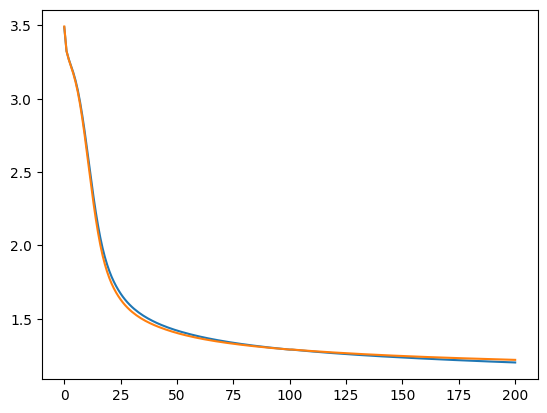

In [17]:
loss_trainset,score_trainset,temps,loss_testset,score_testset=modele.loss_score(modele)
plt.plot(loss_trainset,label='loss_trainset')
plt.plot(loss_testset,label='loss_testset')
#plt.legend()

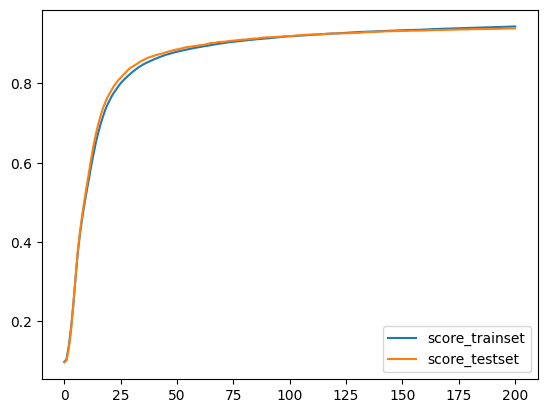

In [18]:
plt.plot(score_trainset,label='score_trainset')
plt.plot(score_testset,label='score_testset')
plt.legend()

In [19]:
#plt.plot(modele.modele_save[0]['loss_trainset'],label='loss_trainset')
#plt.plot(modele.modele_save[-1]['score_trainset'],label='score_trainset')
#plt.plot(modele.modele_save[-3]['score_trainset'],label='score_testset')